# OCR - Convert Scanned SOR to Searchable PDF
### AI Estimation Agent - Nagaland PWD SOR 2021

Your SOR PDF is scanned (images). This notebook:
1. Reads each page as an image
2. Runs OCR (text recognition) on it
3. Saves a new searchable PDF + clean CSV

**Run every cell top to bottom**

## Step 1 - Install Required Tools

**You also need Tesseract OCR engine installed on your PC:**

Download and install from:
https://github.com/UB-Mannheim/tesseract/wiki

During install, note the path (usually `C:\Program Files\Tesseract-OCR\tesseract.exe`)

Also need Poppler for PDF rendering:
https://github.com/oschwartz10612/poppler-windows/releases
Extract it and note the `bin` folder path.

In [1]:
!pip install pytesseract pdf2image Pillow pandas openpyxl pdfplumber -q
print("Libraries installed")

Libraries installed



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2 - Imports

In [2]:
import os
import re
import json
import pandas as pd
from pathlib import Path
from PIL import Image
import pytesseract
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')
print("Imports OK")

Imports OK


## Step 3 - Configuration
Set your file paths below. **Read the comments carefully.**

In [5]:
# Your scanned SOR PDF filename (must be in the same folder as this notebook)
PDF_PATH = "NPWD-SOR-Volume-Isplit.pdf"   # change if your filename is different

# Tesseract path - where you installed Tesseract
# Windows default:
TESSERACT_PATH = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
# If you installed it elsewhere, update the path above

# Poppler path - the bin folder inside where you extracted poppler
# Example: r"C:\poppler-24.02.0\Library\bin"
POPPLER_PATH = r"C:\poppler\Library\bin"   # update this

# Output filenames
OUTPUT_CSV  = "sor_clean.csv"
OUTPUT_XLSX = "sor_clean.xlsx"
OCR_TEXT    = "sor_ocr_raw.txt"   # raw OCR text saved here for review

# OCR Settings
DPI = 300          # higher = better quality but slower. 300 is recommended
START_PAGE = 1     # which page to start from (skip cover pages)
END_PAGE   = None  # set to a number to process only part of the PDF, None = all pages

# Set tesseract path
pytesseract.pytesseract.tesseract_cmd = TESSERACT_PATH

# Verify setup
errors = []
if not os.path.exists(PDF_PATH):
    errors.append(f"PDF not found: {PDF_PATH}")
if not os.path.exists(TESSERACT_PATH):
    errors.append(f"Tesseract not found: {TESSERACT_PATH}")
    errors.append("Download from: https://github.com/UB-Mannheim/tesseract/wiki")

if errors:
    for e in errors:
        print(f"ERROR: {e}")
else:
    size_mb = os.path.getsize(PDF_PATH) / (1024*1024)
    print(f"PDF found      : {PDF_PATH} ({size_mb:.1f} MB)")
    print(f"Tesseract found: {TESSERACT_PATH}")
    ver = pytesseract.get_tesseract_version()
    print(f"Tesseract ver  : {ver}")
    print("Setup OK - ready to run OCR")

PDF found      : NPWD-SOR-Volume-Isplit.pdf (1.7 MB)
Tesseract found: C:\Program Files\Tesseract-OCR\tesseract.exe
Tesseract ver  : 5.5.0.20241111
Setup OK - ready to run OCR


## Step 4 - Preview One Page
Renders page 3 of your PDF as an image so you can see what the scanner captured.
Change `PREVIEW_PAGE` to look at any page.

Rendering page 87...


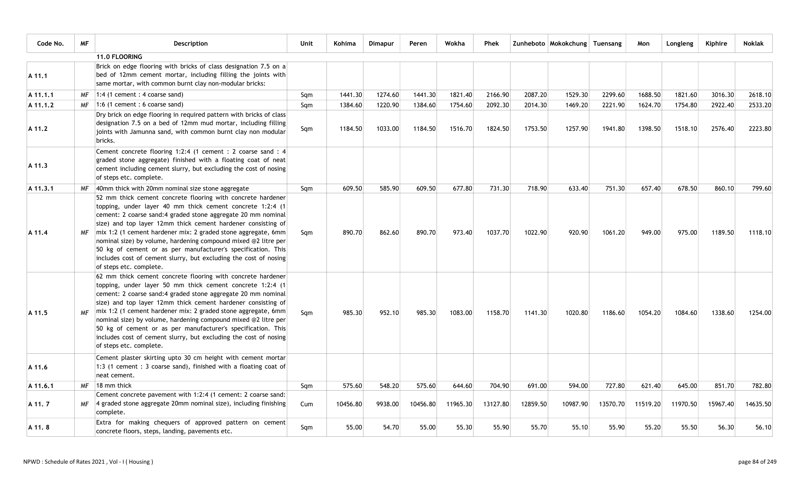

Page size: 2100 x 1275 px


In [6]:
from pdf2image import convert_from_path

PREVIEW_PAGE = 87   # change to any page number

print(f'Rendering page {PREVIEW_PAGE}...')
try:
    pages = convert_from_path(
        PDF_PATH, dpi=150,
        first_page=PREVIEW_PAGE,
        last_page=PREVIEW_PAGE,
        poppler_path=POPPLER_PATH if os.path.exists(POPPLER_PATH) else None
    )
except Exception as e:
    print(f"Error: {e}")
    print(f"Poppler path checked: {POPPLER_PATH}")
    print(f"Path exists: {os.path.exists(POPPLER_PATH)}")
    raise
img = pages[0]
w, h = img.size
scale = min(800/w, 1000/h)
img_small = img.resize((int(w*scale), int(h*scale)))
# ensure /tmp exists (works on Unix and Windows where '/tmp' maps to a valid location)
os.makedirs('/tmp', exist_ok=True)
preview_path = os.path.join('/tmp', 'preview.jpg')
img_small.save(preview_path, 'JPEG', quality=85)

from IPython.display import Image as IPImage
display(IPImage('/tmp/preview.jpg'))
print(f'Page size: {w} x {h} px')

## Step 5 - Test OCR on One Page
Run OCR on a single page first to check quality before processing the full PDF.
Look at the output - can you read the SOR items, units, rates?

In [10]:
import shutil

TEST_PAGE = 87   # pick a page that has actual SOR items (not cover/index)

print(f'Running OCR on page {TEST_PAGE}...')
pages = convert_from_path(
    PDF_PATH, dpi=DPI,
    first_page=TEST_PAGE,
    last_page=TEST_PAGE,
    poppler_path=POPPLER_PATH if os.path.exists(POPPLER_PATH) else None
)

img = pages[0]
# OCR config: treat as single column, optimize for tables
custom_config = r'--oem 3 --psm 6'
if os.path.exists(TESSERACT_PATH):
    pytesseract.pytesseract.tesseract_cmd = TESSERACT_PATH
else:
    found = shutil.which("tesseract")
    if found:
        pytesseract.pytesseract.tesseract_cmd = found
    else:
        # try common install locations before failing
        common_paths = [
            r"C:\Program Files\Tesseract-OCR\tesseract.exe",
            r"C:\Program Files (x86)\Tesseract-OCR\tesseract.exe"
        ]
        for p in common_paths:
            if os.path.exists(p):
                pytesseract.pytesseract.tesseract_cmd = p
            print(f"Found Tesseract at: {p}")
            break

            
            
        else:
            raise FileNotFoundError(
            "Tesseract executable not found. Install Tesseract and update TESSERACT_PATH "
            "or add it to PATH. See: https://github.com/UB-Mannheim/tesseract/wiki"
            )

text = pytesseract.image_to_string(img, config=custom_config)

print(f'--- OCR OUTPUT - PAGE {TEST_PAGE} ---')
print(text[:1500])
print(f'--- Total characters: {len(text)} ---')

if len(text) < 100:
    print()
    print('WARNING: Very little text extracted.')
    print('Try increasing DPI to 400 or check if image is clear.')
else:
    print()
    print('OCR working. Proceed to Step 6 to process full PDF.')

Running OCR on page 87...
--- OCR OUTPUT - PAGE 87 ---
i ne
11.0 FLOORING
Brick on edge flooring with bricks of class designation 7.5 on a
A11.1 bed of 12mm cement mortar, including filling the joints with
same mortar, with common burnt clay non-modular bricks:
A 11.1.1 MF 1:4 (1 cement : 4 coarse sand) Sqm 1441.30 1274.60 1441.30 1821.40 2166.90 2087.20 1529.30 2299.60 1688.50 1821.60 3016.30 2618.10
A 11.1.2 MF 1:6 (1 cement : 6 coarse sand) Sqm 1384.60 1220.90 1384.60 1754.60 2092.30 2014.30 1469.20 2221.90 1624.70 1754.80 2922.40 2533.20
Dry brick on edge flooring in required pattern with bricks of class
designation 7.5 on a bed of 12mm mud mortar, including filling
A 11.2 joints with Jamunna sand, with common burnt clay non modular Sqm 1184.50 1033.00 1184.50 1516.70 1824.50 1753.50 1257.90 1941.80 1398.50 1518.10 2576.40 2223.80
bricks.
Cement concrete flooring 1:2:4 (1 cement : 2 coarse sand : 4
graded stone aggregate) finished with a floating coat of neat
A 11.3 cement includin

## Step 6 - Run OCR on Full PDF
Processes every page. Can take **5-20 minutes** depending on PDF size.
Progress is shown as it runs.

In [11]:
from pdf2image import convert_from_path

# Load PDF info
from pypdf import PdfReader
total_pages = len(PdfReader(PDF_PATH).pages)
start = START_PAGE
end   = END_PAGE if END_PAGE else total_pages

print(f'PDF: {total_pages} total pages')
print(f'Processing pages {start} to {end}')
print(f'DPI: {DPI}')
print('Starting OCR... (this will take a while)')
print()

all_text   = []
page_texts = {}

for page_num in range(start, end + 1):
    try:
        pages = convert_from_path(
            PDF_PATH, dpi=DPI,
            first_page=page_num,
            last_page=page_num,
            poppler_path=POPPLER_PATH if os.path.exists(POPPLER_PATH) else None
        )
        img  = pages[0]
        text = pytesseract.image_to_string(img, config=r'--oem 3 --psm 6')
        page_texts[page_num] = text
        all_text.append(f'=== PAGE {page_num} ===\n{text}\n')
        print(f'  Page {page_num:4d}/{end}  |  {len(text):5d} chars extracted', end='\r')
    except Exception as e:
        print(f'  Page {page_num} error: {e}')
        page_texts[page_num] = ''

print(f'\nOCR complete! Processed {len(page_texts)} pages.')

# Save raw OCR text
full_text = '\n'.join(all_text)
with open(OCR_TEXT, 'w', encoding='utf-8') as f:
    f.write(full_text)
print(f'Raw OCR text saved to: {OCR_TEXT}')
print(f'Total characters: {len(full_text)}')

PDF: 288 total pages
Processing pages 1 to 288
DPI: 300
Starting OCR... (this will take a while)

  Page  288/288  |   1073 chars extracted
OCR complete! Processed 288 pages.
Raw OCR text saved to: sor_ocr_raw.txt
Total characters: 801672


# My Step

In [13]:
INPUT_FILE  = "sor_ocr_raw.txt"   # your OCR output from Step 6
OUTPUT_CSV  = "sor_clean.csv"
OUTPUT_XLSX = "sor_clean.xlsx"

import os
if os.path.exists(INPUT_FILE):
    size = os.path.getsize(INPUT_FILE) / 1024
    print(f"File found: {INPUT_FILE} ({size:.1f} KB)")
else:
    print(f"ERROR: {INPUT_FILE} not found.")
    print("Run Step 6 of 0_OCR_SOR.ipynb first.")

File found: sor_ocr_raw.txt (796.6 KB)


In [15]:
with open(INPUT_FILE, "r", encoding="utf-8", errors="ignore") as f:
    raw_text = f.read()

print(f"Total characters : {len(raw_text):,}")
print(f"Total lines      : {raw_text.count(chr(10)):,}")
print(f"Total pages      : {raw_text.count('=== PAGE'):,}")
print()
print("First 500 chars preview:")
print(raw_text[:500])

Total characters : 801,672
Total lines      : 12,824
Total pages      : 288

First 500 chars preview:
=== PAGE 1 ===
INDEX
Description of Works Page
ICHAPTER-2 | EARTHWORK
ICHAPTER-4 | CONCRETEWORK
ICHAPTER-5 | _REINFORCEDCEMENTCONCRETE | 1S
ICHAPTER-6 | BRICKWORK
ICHAPTER-7 | STONEWORK
ICHAPTER-8 | CLADDINGWORK
[CHAPTER-11[ FLOORING
[CHAPTER-12[ ROOFING CH
ICHAPTER-13| FINISHING
CHAPTER: 14| REPAIRSTOBUILDINGS 8
[CHAPTER-15| DISMANTLING &DEMOLISHING 188
ICHAPTER-17|__SANITARYINSTALLATIONS 1
ICHAPTER-18| WATERSUPPLY
ICHAPTER-19| DRAINAGE 8
ICHAPTER-20| PILEWORK 8
CHAPTER: 22| WATERPROOFING 202
I


# SOR Pharaphase

In [16]:
# All unit keywords found in NPWD SOR 2021
UNITS_PATTERN = (
    r'(100\s*Sqm|100\s*Cum|100\s*Metre|100\s*Rmt|'
    r'Sqm|Cum|Metre|Rmt|Kg|Nos|Lump|MT|RM|Set|Job|Each|'
    r'sqm|cum|metre|rmt|kg|nos|lump|mt|rm|set|job|each)'
)

# Item number pattern: A 2.1.1 or A2.10.1.1 or A2.4
ITEM_PATTERN = re.compile(
    r'(A\s*\d+(?:[\.\/]\d+)*)\s+'   # item number
    r'([\|\s]*)(.+?)\s+'              # optional pipe + description
    r'[\|\s]*' + UNITS_PATTERN + r'\s*'  # unit
    r'[\|\s]*'
    r'([\d,]+\.?\d*)',               # first rate (base rate)
    re.IGNORECASE
)


def clean_description(desc):
    # Remove leading/trailing pipes and spaces
    desc = desc.strip().strip('|').strip()
    # Remove multiple spaces
    desc = re.sub(r'\s+', ' ', desc)
    # Remove OCR artifacts
    desc = re.sub(r'[\[\]{}]', '', desc)
    return desc.strip()


def clean_rate(rate_str):
    try:
        return float(rate_str.replace(',', '').replace('.', '', rate_str.count('.')-1) 
                     if rate_str.count('.') > 1 
                     else rate_str.replace(',', ''))
    except:
        return 0.0


def parse_sor(text):
    records = []
    current_chapter = ''
    lines = text.split('\n')
    
    # Track multi-line descriptions
    # Some items have description split across lines before the sub-item
    pending_desc = ''

    for i, line in enumerate(lines):
        line_stripped = line.strip()
        
        # Detect chapter headings
        ch_match = re.search(r'(\d+\.0\s+[A-Z][A-Z\s]+)', line_stripped)
        if ch_match and len(line_stripped) < 60:
            current_chapter = ch_match.group(1).strip()
            continue
        
        # Also catch chapter from CHAPTER-N headings
        if re.match(r'[A-Z0-9\s]+WORK|EARTHWORK|FLOORING|FINISHING|ROOFING|SANITARY|DRAINAGE', line_stripped, re.I):
            if len(line_stripped) < 50:
                current_chapter = line_stripped
                continue
        
        # Try to match a full SOR item line
        match = ITEM_PATTERN.search(line_stripped)
        if match:
            item_no = match.group(1).strip().replace(' ', '')
            desc    = clean_description(match.group(3))
            unit    = match.group(4).strip()
            rate    = clean_rate(match.group(5))
            
            # Skip if description is too short (likely a noise match)
            if len(desc) < 3:
                desc = pending_desc if pending_desc else desc
            
            # Skip zero or very low rates (likely parsing errors)
            if rate < 0.5:
                continue
            
            records.append({
                'item_no':     item_no,
                'chapter':     current_chapter,
                'description': desc,
                'unit':        unit.strip(),
                'rate':        rate,
            })
            pending_desc = ''
        else:
            # This line might be a description continuation
            # Store it as pending if it looks like real text
            if (len(line_stripped) > 15 
                and not line_stripped.startswith('===')
                and not line_stripped.startswith('NPWD')
                and not re.match(r'^[\d\s\.]+$', line_stripped)):
                pending_desc = line_stripped

    return pd.DataFrame(records)


print("Parser defined and ready")

Parser defined and ready


# Run Pharaphrase on Full OCR text

In [21]:
print("Parsing SOR text...")
df = parse_sor(raw_text)

print(f"Total items extracted : {len(df)}")
print()

if len(df) > 0:
    print("Sample (first 20 items):")
    display(df.head(100))
else:
    print("WARNING: Nothing extracted. Check Step 6 output.")

Parsing SOR text...
Total items extracted : 2103

Sample (first 20 items):


,item_no,chapter,description,unit,rate
0,A2.1.1,2.0 EARTHWORK,All Kinds of Soil,100 Sqm,7465.7
1,A2.2.1,2.0 EARTHWORK,All Kinds of soil,Cum,604.9
2,A2.3.1,2.0 EARTHWORK,All kinds of soil,Cum,382.7
3,A2.4,2.0 EARTHWORK,banking excavated earth in layers not exceedin...,Cum,6.4
4,A2.5,2.0 EARTHWORK,Deduct for not watering the excavated earth fo...,Cum,26.8
...,...,...,...,...,...
95,A4.9,removal of form work for:,embedded 150 in cement concrete 1:3:6 ( 1cemen...,Each,862.4
96,A4.10,removal of form work for:,MF concrete 1:2:4 (1 Cement : 2 coarse sand : ...,Sqm,875.4
97,A4.11,removal of form work for:,MF concrete 1:2:4 (1 Cement : 2 coarse sand : ...,Sqm,572.5
98,A4.13,removal of form work for:,MF course after cleaning the surface with brus...,Sqm,157.5


# Review extraction state

In [22]:
if len(df) > 0:
    print("=" * 50)
    print("  EXTRACTION SUMMARY")
    print("=" * 50)
    print(f"  Total items        : {len(df)}")
    print(f"  Items with rate >0 : {(df.rate > 0).sum()}")
    print(f"  Items with rate =0 : {(df.rate == 0).sum()}")
    print(f"  Unique chapters    : {df.chapter.nunique()}")
    print()
    print("  Units breakdown:")
    print(df['unit'].value_counts().to_string())
    print()
    print("  Chapters found:")
    for ch in df['chapter'].unique():
        count = len(df[df["chapter"]==ch])
        print(f"    {ch[:50]:50s} | {count} items")
    print()
    print("  Rate range:")
    print(f"    Min: Rs.{df.rate.min():.2f}")
    print(f"    Max: Rs.{df.rate.max():.2f}")
    print(f"    Avg: Rs.{df.rate.mean():.2f}")

  EXTRACTION SUMMARY
  Total items        : 2103
  Items with rate >0 : 2103
  Items with rate =0 : 0
  Unique chapters    : 37

  Units breakdown:
unit
Each       797
Sqm        593
Metre      446
Cum        201
Kg          37
kg          11
Nos          6
sqm          5
Set          4
metre        2
100 Sqm      1

  Chapters found:
    2.0 EARTHWORK                                      | 73 items
    4.0 CONCRETE WORK                                  | 14 items
    removal of form work for:                          | 15 items
    finishing the top smooth.                          | 8 items
    5.0 REINFORCED CEMENT CONCRETE                     | 89 items
    6.0 BRICKWORK                                      | 38 items
    Brick work with common burnt clay machine moulded  | 18 items
    7.0 STONE WORK                                     | 112 items
    9.0 WOOD                                           | 293 items
    10.0 STEEL WORKS                                   | 48 items
  

# Spot check

In [23]:
# Search for items by keyword
# Change the keyword to check different items
keyword = "earthwork"    # try: "concrete", "brick", "plaster", "steel"

results = df[df['description'].str.contains(keyword, case=False, na=False)]
print(f"Items matching '{keyword}': {len(results)}")
print()
display(results[['item_no','description','unit','rate']].head(15))

Items matching 'earthwork': 0



,item_no,description,unit,rate


In [24]:
def enrich_descriptions(text, df):
    """
    For each item, find its parent description block in the raw text
    and prepend it to give full context.
    """
    enriched = []
    lines = text.split('\n')
    
    for _, row in df.iterrows():
        item_no_raw = row['item_no']   # e.g. A2.2.1
        desc = row['description']
        
        # If description is meaningful enough, keep as is
        if len(desc) > 40:
            enriched.append(desc)
            continue
        
        # Find the line in raw text where this item appears
        item_pattern = item_no_raw.replace('.', '\\.').replace('A', 'A\\s*')
        found_line = -1
        for j, line in enumerate(lines):
            if re.search(item_pattern, line, re.IGNORECASE):
                found_line = j
                break
        
        if found_line > 0:
            # Collect up to 5 lines before this item
            context_lines = []
            for k in range(max(0, found_line - 6), found_line):
                prev = lines[k].strip()
                if (len(prev) > 15
                    and not prev.startswith('===')
                    and not prev.startswith('NPWD')
                    and not re.match(r'^A\s*\d', prev)
                    and not re.match(r'^[\d\s\.]+$', prev)):
                    context_lines.append(prev)
            
            if context_lines:
                parent_desc = ' '.join(context_lines[-2:])  # last 2 relevant lines
                full_desc = parent_desc.strip() + ' - ' + desc
                enriched.append(full_desc[:200])  # cap at 200 chars
            else:
                enriched.append(desc)
        else:
            enriched.append(desc)
    
    return enriched


print("Enriching short descriptions...")
df['description'] = enrich_descriptions(raw_text, df)
print("Done!")
print()
print("Sample after enrichment:")
display(df[['item_no','description','unit','rate']].head(15))

Enriching short descriptions...
Done!

Sample after enrichment:


,item_no,description,unit,rate
0,A2.1.1,but exceeding 1.5 m in width as well as 10 sqm...,100 Sqm,7465.7
1,A2.2.1,"roads, flood banks, marginal banks and guide b...",Cum,604.9
2,A2.3.1,"dressing up, in embankments for roads, flood b...",Cum,382.7
3,A2.4,banking excavated earth in layers not exceedin...,Cum,6.4
4,A2.5,Deduct for not watering the excavated earth fo...,Cum,26.8
5,A2.6.1,and disposal of excavated earth lead upto 50 m...,Cum,220.9
6,A2.7.1,and disposal of excavated earth lead upto 50 m...,Cum,398.9
7,A2.7.2,and disposal of excavated earth lead upto 50 m...,Cum,731.0
8,A2.7.3,and disposal of excavated earth lead upto 50 m...,Cum,761.5
9,A2.8.1,out the excavated soil and disposal of surplus...,Cum,278.2


# save

In [25]:
# Final cleanup
df_final = df.copy()
df_final = df_final.dropna(subset=['description', 'rate'])
df_final = df_final[df_final['rate'] > 0]
df_final = df_final[df_final['description'].str.len() > 3]
df_final = df_final.drop_duplicates(subset=['item_no'])
df_final = df_final.reset_index(drop=True)

# Save
df_final.to_csv(OUTPUT_CSV, index=False)
df_final.to_excel(OUTPUT_XLSX, index=False)

print(f"Saved: {OUTPUT_CSV}   ({len(df_final)} items)")
print(f"Saved: {OUTPUT_XLSX}  ({len(df_final)} items)")
print()
print("Preview of saved data:")
display(df_final.head(10))
print()
print("=" * 50)
print("NEXT: Open 4_Build_vector.ipynb")
print("It loads sor_clean.csv and builds the AI search index.")
print("=" * 50)

Saved: sor_clean.csv   (2101 items)
Saved: sor_clean.xlsx  (2101 items)

Preview of saved data:


,item_no,chapter,description,unit,rate
0,A2.1.1,2.0 EARTHWORK,but exceeding 1.5 m in width as well as 10 sqm...,100 Sqm,7465.7
1,A2.2.1,2.0 EARTHWORK,"roads, flood banks, marginal banks and guide b...",Cum,604.9
2,A2.3.1,2.0 EARTHWORK,"dressing up, in embankments for roads, flood b...",Cum,382.7
3,A2.4,2.0 EARTHWORK,banking excavated earth in layers not exceedin...,Cum,6.4
4,A2.5,2.0 EARTHWORK,Deduct for not watering the excavated earth fo...,Cum,26.8
5,A2.6.1,2.0 EARTHWORK,and disposal of excavated earth lead upto 50 m...,Cum,220.9
6,A2.7.1,2.0 EARTHWORK,and disposal of excavated earth lead upto 50 m...,Cum,398.9
7,A2.7.2,2.0 EARTHWORK,and disposal of excavated earth lead upto 50 m...,Cum,731.0
8,A2.7.3,2.0 EARTHWORK,and disposal of excavated earth lead upto 50 m...,Cum,761.5
9,A2.8.1,2.0 EARTHWORK,out the excavated soil and disposal of surplus...,Cum,278.2



NEXT: Open 4_Build_vector.ipynb
It loads sor_clean.csv and builds the AI search index.


## Step 7 - Parse OCR Text into SOR Items
Extracts item numbers, descriptions, units and rates from the OCR text.

> After running, scroll down to see the extracted items.
> If many items are missing, share the `sor_ocr_raw.txt` file with me and I will fix the parser.

In [17]:
def parse_sor_from_ocr(text):
    records = []
    lines = text.split('\n')

    # Pattern 1: item_no  description  unit  rate
    # e.g.:  1.01  Earthwork excavation in soft soil  cum  185.00
    pattern_full = re.compile(
        r'^(\d+[\.\/]?\d*)\s{1,}'
        r'(.{10,80}?)\s{2,}'
        r'(cum|sqm|sqft|rmt|kg|nos|lump|litre|MT|RM|Rmt|Ltr|set|job)\s+'
        r'([\d,]+\.?\d*)\s*$',
        re.IGNORECASE
    )

    # Pattern 2: looser match for lines where columns are closer together
    pattern_loose = re.compile(
        r'^(\d+[\.\/]?\d*)\s+'
        r'(.{8,})\s+'
        r'(cum|sqm|sqft|rmt|kg|nos|lump|MT|RM)\s+'
        r'([\d,]+\.\d{2})',
        re.IGNORECASE
    )

    for line in lines:
        line = line.strip()
        if len(line) < 10:
            continue

        match = pattern_full.match(line) or pattern_loose.search(line)
        if match:
            records.append({
                'item_no':     match.group(1).strip(),
                'description': match.group(2).strip(),
                'unit':        match.group(3).strip().lower(),
                'rate':        float(match.group(4).replace(',', ''))
            })

    return pd.DataFrame(records)


print('Parsing OCR text for SOR items...')
df = parse_sor_from_ocr(full_text)

print(f'Items extracted: {len(df)}')
print()

if len(df) > 0:
    print('Sample (first 20 items):')
    display(df.head(20))
    print()
    print(f'Rate range: Rs.{df.rate.min():.2f} to Rs.{df.rate.max():.2f}')
    print(f'Units found: {df.unit.unique().tolist()}')
else:
    print('WARNING: No items extracted.')
    print('The regex may need adjustment for your SOR layout.')
    print('Share the sor_ocr_raw.txt file and I will fix the parser.')

Parsing OCR text for SOR items...
Items extracted: 0

The regex may need adjustment for your SOR layout.
Share the sor_ocr_raw.txt file and I will fix the parser.


## Step 8 - Manual Review
Look at the extracted items above carefully.

Common issues and fixes:
- **Description is cut off** - OCR may have split lines, adjust regex
- **Rate shows 0** - Rate column not captured, share raw text with me
- **Too few items** - Unit keywords missing, add them to the pattern

You can also open `sor_ocr_raw.txt` in VS Code to manually inspect the raw OCR output.

In [ ]:
# Quick stats on extracted data
if len(df) > 0:
    print('=== EXTRACTION SUMMARY ===')
    print(f'Total items extracted : {len(df)}')
    print(f'Items with rate > 0   : {(df.rate > 0).sum()}')
    print(f'Items with rate = 0   : {(df.rate == 0).sum()}')
    print()
    print('Units breakdown:')
    print(df.unit.value_counts().to_string())
    print()
    print('Rate distribution:')
    print(df.rate.describe().round(2).to_string())

## Step 9 - Save to CSV and Excel
Saves the cleaned SOR data. These files are used by the next notebooks.

In [ ]:
if len(df) > 0:
    # Clean up
    df = df.dropna(subset=['description', 'rate'])
    df = df[df['rate'] > 0]
    df = df[df['description'].str.len() > 5]
    df = df.reset_index(drop=True)

    df.to_csv(OUTPUT_CSV, index=False)
    df.to_excel(OUTPUT_XLSX, index=False)

    print(f'Saved: {OUTPUT_CSV}   ({len(df)} items)')
    print(f'Saved: {OUTPUT_XLSX}  ({len(df)} items)')
    print()
    print('Next step: Open 4_Build_vector.ipynb')
    print('It will load sor_clean.csv and build the AI search index.')
else:
    print('Nothing to save - check Step 7 output.')
    print('Share sor_ocr_raw.txt and I will fix the parser for your SOR layout.')